# Samokat ESCI: загрузка и базовый EDA

Стартовая тетрадка для знакомства с датасетом `samokat_esci.csv`: загрузка данных, быстрая проверка качества, базовые агрегации и визуализации по ESCI-разметке и категориям товаров.

## Оглавление

1. Подготовка
2. Статистики
3. Граф заменителей из S-меток
4. Граф сопутствующих товаров из C-меток

## 1. Подготовка

В этом блоке собраны импорт библиотек, загрузка и очистка данных, основные статистики по ESCI-меткам, категориям и запросам, а также простой текстовый признак.



### 1.1 Импорт библиотек

Если в Jupyter не установлены библиотеки для визуализации, раскомментируйте и выполните строку с `%pip install`.

In [1]:
# Если библиотек нет в вашем Jupyter-окружении, раскомментируйте строку ниже и выполните ячейку.
# %pip install pandas matplotlib seaborn

# Path помогает удобно работать с путями к файлам на компьютере.
from pathlib import Path

# numpy нужен для числовых операций и специального значения np.nan.
import numpy as np

# pandas нужен для чтения CSV, таблиц, группировок и расчёта статистик.
import pandas as pd

# matplotlib отвечает за базовую отрисовку графиков.
import matplotlib.pyplot as plt

# seaborn строит более аккуратные статистические графики поверх matplotlib.
import seaborn as sns

# Показываем до 50 колонок в pandas-таблицах, чтобы ничего важного не скрывалось.
pd.set_option("display.max_columns", 50)

# Расширяем видимую длину текстовых значений, чтобы названия товаров не обрезались слишком рано.
pd.set_option("display.max_colwidth", 120)

# Задаём общий стиль графиков: сетка на фоне и спокойная цветовая палитра.
sns.set_theme(style="whitegrid", palette="Set2")

### 1.1 Загрузка CSV

CSV должен лежать рядом с тетрадкой. Используем `utf-8-sig`, чтобы корректно обработать возможный BOM в начале файла.

In [2]:
# Указываем абсолютный путь к исходному CSV-файлу.
DATA_PATH = Path("data.csv")

# Читаем CSV в pandas DataFrame; utf-8-sig корректно обрабатывает возможный BOM в начале файла.
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

# Выводим первые 5 строк, чтобы быстро проверить, что данные загрузились правильно.
df_raw.head()

,query,item_name,item_id,final_answer,category4_name,category3_name,category2_name,category1_name
0,энергетик без сахара,"энергетик самокат, без сахара, с соком малины, 0,33 л",55e4ae6a298cf3f69d8e07a92ec9e6a0,e,энергетические напитки,энергетические напитки,напитки,безалкогольные напитки
1,салат из рубца,"салат кх волкова а. п. деревенский, 150 г",b429835fc94f84edf3e319f01ce35274,s,салаты с майонезом,салаты,готовые блюда,кулинария
2,барилла,"макароны barilla, пенне ригате, 450 г",a2f84d68a96b5f95e3b72ff3f664e1e6,e,фигурные,"спагетти, фигурные",макаронные изделия,бакалея
3,краска для волос орех,"спрей-уход для наращенных волос tashe 250 мл, 1 шт.",227b20c1eee7ba92f52dfaf6fe9c05c4,c,натуральные краски для волос,краска для волос,средства по уходу за волосами,уход
4,творог мя,"творог козочка с облачка, 5%, мягкий, из козьего молока, кокосовые сливки, 100 г",05180ad0ea61952acd22c82f5740c47b,e,мягкий творог,творог,кисломолочные традиционные продукты,молочная продукция


In [3]:
# Печатаем количество строк; replace нужен только для красивого разделения тысяч пробелом.
print(f"Строк: {df_raw.shape[0]:,}".replace(",", " "))

# Печатаем количество колонок в таблице.
print(f"Колонок: {df_raw.shape[1]}")

# Показываем типы колонок, количество непустых значений и примерный объём памяти.
df_raw.info(memory_usage="deep")

Строк: 79 774
Колонок: 8
<class 'pandas.DataFrame'>
RangeIndex: 79774 entries, 0 to 79773
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   query           79774 non-null  str  
 1   item_name       79774 non-null  str  
 2   item_id         79774 non-null  str  
 3   final_answer    79774 non-null  str  
 4   category4_name  79774 non-null  str  
 5   category3_name  79727 non-null  str  
 6   category2_name  79194 non-null  str  
 7   category1_name  79054 non-null  str  
dtypes: str(8)
memory usage: 61.2 MB


### 1.2 Минимальная очистка и признаки

Приведём текст к строковому типу, уберём лишние пробелы, нормализуем ESCI-метку и добавим несколько простых признаков для дальнейшей визуализации.

In [4]:
# Перечисляем текстовые колонки, которые будем приводить к единому виду.
TEXT_COLUMNS = [
    # Поисковый запрос пользователя.
    "query",
    # Название товара из каталога.
    "item_name",
    # Уникальный идентификатор товара.
    "item_id",
    # Категория верхнего уровня.
    "category1_name",
    # Категория второго уровня.
    "category2_name",
    # Категория третьего уровня.
    "category3_name",
    # Самая детальная категория.
    "category4_name",
]

# Создаём копию исходных данных, чтобы df_raw остался неизменным для проверок.
df = df_raw.copy()

# Проходим по всем текстовым колонкам из списка выше.
for col in TEXT_COLUMNS:
    # Переводим колонку в строковый тип pandas и убираем пробелы в начале/конце значений.
    df[col] = df[col].astype("string").str.strip()

# Нормализуем ESCI-метку: делаем строкой, убираем пробелы и переводим в верхний регистр.
df["final_answer"] = df["final_answer"].astype("string").str.strip().str.upper()

# Собираем список колонок с категориями, чтобы обработать их одинаково.
category_cols = ["category1_name", "category2_name", "category3_name", "category4_name"]

# Заменяем пропуски в категориях понятной заглушкой, чтобы они не терялись в группировках.
df[category_cols] = df[category_cols].fillna("<нет категории>")

# Считаем длину поискового запроса в символах.
df["query_len"] = df["query"].str.len()

# Считаем длину поискового запроса в словах.
df["query_words"] = df["query"].str.split().str.len()

# Считаем длину названия товара в символах.
df["item_len"] = df["item_name"].str.len()

# Считаем длину названия товара в словах.
df["item_words"] = df["item_name"].str.split().str.len()

# Показываем первые строки уже очищенной и дополненной таблицы.
df.head()

,query,item_name,item_id,final_answer,category4_name,category3_name,category2_name,category1_name,query_len,query_words,item_len,item_words
0,энергетик без сахара,"энергетик самокат, без сахара, с соком малины, 0,33 л",55e4ae6a298cf3f69d8e07a92ec9e6a0,E,энергетические напитки,энергетические напитки,напитки,безалкогольные напитки,20,3,53,9
1,салат из рубца,"салат кх волкова а. п. деревенский, 150 г",b429835fc94f84edf3e319f01ce35274,S,салаты с майонезом,салаты,готовые блюда,кулинария,14,3,41,8
2,барилла,"макароны barilla, пенне ригате, 450 г",a2f84d68a96b5f95e3b72ff3f664e1e6,E,фигурные,"спагетти, фигурные",макаронные изделия,бакалея,7,1,37,6
3,краска для волос орех,"спрей-уход для наращенных волос tashe 250 мл, 1 шт.",227b20c1eee7ba92f52dfaf6fe9c05c4,C,натуральные краски для волос,краска для волос,средства по уходу за волосами,уход,21,4,51,9
4,творог мя,"творог козочка с облачка, 5%, мягкий, из козьего молока, кокосовые сливки, 100 г",05180ad0ea61952acd22c82f5740c47b,E,мягкий творог,творог,кисломолочные традиционные продукты,молочная продукция,9,2,80,13


In [5]:
# Собираем небольшую таблицу с основными характеристиками датасета.
summary = pd.DataFrame(
    {
        # Названия метрик, которые хотим посчитать.
        "metric": [
            # Общее количество строк.
            "rows",
            # Количество уникальных поисковых запросов.
            "unique_queries",
            # Количество уникальных товаров.
            "unique_items",
            # Количество уникальных категорий первого уровня.
            "unique_category1",
            # Количество уникальных категорий четвертого уровня.
            "unique_category4",
            # Количество повторяющихся пар запрос-товар.
            "duplicate_pairs",
        ],
        # Значения соответствующих метрик.
        "value": [
            # len(df) возвращает число строк в DataFrame.
            len(df),
            # nunique считает количество уникальных запросов.
            df["query"].nunique(),
            # nunique считает количество уникальных item_id.
            df["item_id"].nunique(),
            # nunique считает количество уникальных категорий 1-го уровня.
            df["category1_name"].nunique(),
            # nunique считает количество уникальных категорий 4-го уровня.
            df["category4_name"].nunique(),
            # duplicated помечает повторы пары query + item_id, sum считает их количество.
            df.duplicated(["query", "item_id"]).sum(),
        ],
    }
)

# Выводим итоговую таблицу с метриками.
summary

,metric,value
0,rows,79774
1,unique_queries,9496
2,unique_items,33345
3,unique_category1,60
4,unique_category4,2219
5,duplicate_pairs,0


In [6]:
# Строим таблицу с количеством и долей пропусков по каждой колонке.
missing = (
    # isna даёт True там, где значение пропущено.
    df_raw.isna()
    # sum считает число True, то есть количество пропусков по каждой колонке.
    .sum()
    # Переименовываем получившуюся серию в missing_count.
    .rename("missing_count")
    # Превращаем серию в DataFrame, чтобы добавить вторую колонку.
    .to_frame()
    # Добавляем долю пропусков: число пропусков делим на количество строк.
    .assign(missing_share=lambda x: x["missing_count"] / len(df_raw))
    # Сортируем так, чтобы колонки с максимальным числом пропусков были сверху.
    .sort_values("missing_count", ascending=False)
)

# Выводим таблицу пропусков.
missing

,missing_count,missing_share
category1_name,720,0.009025
category2_name,580,0.007271
category3_name,47,0.000589
query,0,0.000000
item_name,0,0.000000
item_id,0,0.000000
final_answer,0,0.000000
category4_name,0,0.000000


## 2 Статистики

### 2.1 Распределение ESCI-разметки

Посмотрим, каких типов релевантности больше: `E` — точное совпадение, `S` — заменитель, `C` — дополнение, `I` — нерелевантно.

In [7]:
# Задаём желаемый порядок ESCI-меток на графиках и в таблицах.
label_order = ["E", "S", "C", "I"]

# Считаем количество строк для каждой ESCI-метки.
label_counts = (
    # Берём колонку с разметкой релевантности.
    df["final_answer"]
    # value_counts считает частоту каждой метки; dropna=False не скрывает пропуски.
    .value_counts(dropna=False)
    # Даём индексу имя, чтобы после reset_index получить понятную колонку.
    .rename_axis("final_answer")
    # Превращаем результат в обычную таблицу с колонкой count.
    .reset_index(name="count")
)

# Добавляем долю каждой метки от общего числа строк.
label_counts["share"] = label_counts["count"] / label_counts["count"].sum()

# Выводим таблицу с количеством и долями меток.
label_counts

,final_answer,count,share
0,E,36474,0.457217
1,I,29160,0.365533
2,S,9307,0.116667
3,C,4833,0.060584


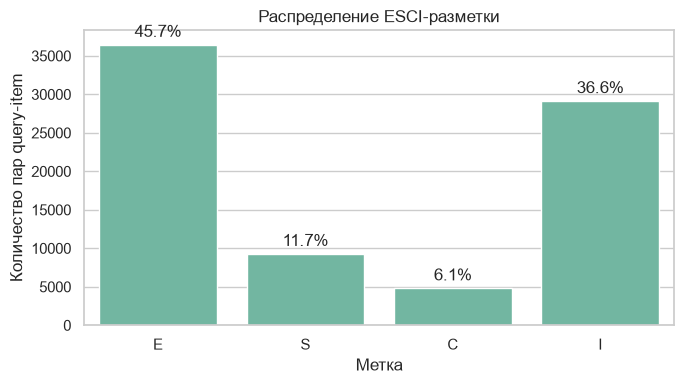

In [8]:
# Создаём область для графика размером 7 на 4 дюйма.
plt.figure(figsize=(7, 4))

# Строим столбчатый график количества строк по ESCI-меткам.
ax = sns.countplot(data=df, x="final_answer", order=label_order)

# Добавляем заголовок графика.
ax.set_title("Распределение ESCI-разметки")

# Подписываем ось X.
ax.set_xlabel("Метка")

# Подписываем ось Y.
ax.set_ylabel("Количество пар query-item")

# Сохраняем общее число строк, чтобы посчитать проценты для подписей.
total = len(df)

# Проходим по контейнерам столбиков на графике.
for container in ax.containers:
    # Подписываем каждый столбик долей от общего числа строк.
    ax.bar_label(container, labels=[f"{v / total:.1%}" for v in container.datavalues], padding=3)

# Автоматически подгоняем отступы, чтобы подписи не обрезались.
plt.tight_layout()

### 2.2 Категории товаров

Сначала посмотрим верхний уровень дерева категорий, затем — как в крупных категориях распределяются ESCI-метки.

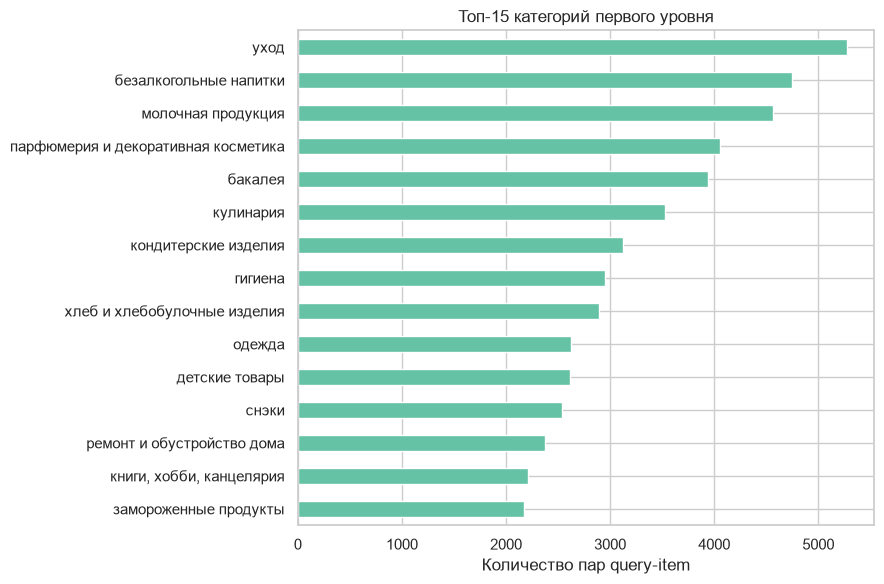

In [9]:
# Считаем частоту категорий первого уровня и оставляем 15 самых крупных.
top_category1 = (
    # Берём колонку с верхним уровнем категорий.
    df["category1_name"]
    # Считаем количество строк в каждой категории.
    .value_counts()
    # Оставляем 15 самых частых категорий.
    .head(15)
    # Сортируем по возрастанию, чтобы горизонтальный bar chart читался снизу вверх.
    .sort_values()
)

# Создаём область для графика размером 9 на 6 дюймов.
plt.figure(figsize=(9, 6))

# Строим горизонтальную столбчатую диаграмму.
ax = top_category1.plot(kind="barh")

# Добавляем заголовок графика.
ax.set_title("Топ-15 категорий первого уровня")

# Подписываем ось X.
ax.set_xlabel("Количество пар query-item")

# Убираем подпись оси Y, потому что названия категорий уже видны как метки.
ax.set_ylabel("")

# Подгоняем отступы графика.
plt.tight_layout()

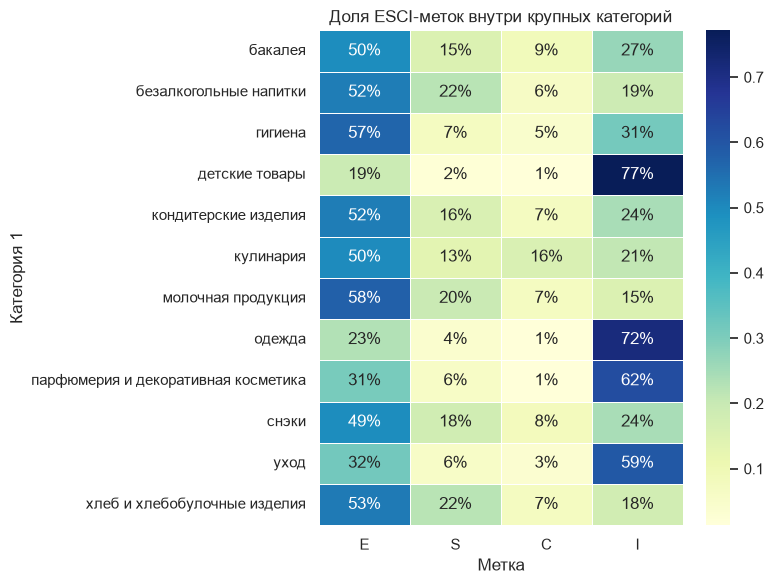

In [10]:
# Берём названия 12 самых частых категорий первого уровня.
top_cat_names = df["category1_name"].value_counts().head(12).index

# Строим таблицу: строки — категории, колонки — ESCI-метки, значения — доли меток внутри категории.
label_by_cat = pd.crosstab(
    # Фильтруем строки только по крупным категориям и берём category1_name для строк таблицы.
    df.loc[df["category1_name"].isin(top_cat_names), "category1_name"],
    # Для тех же строк берём final_answer для колонок таблицы.
    df.loc[df["category1_name"].isin(top_cat_names), "final_answer"],
    # normalize='index' превращает количества в доли внутри каждой строки-категории.
    normalize="index",
    # Переупорядочиваем колонки в привычном порядке E, S, C, I.
).reindex(columns=label_order)

# Создаём область для тепловой карты.
plt.figure(figsize=(8, 6))

# Рисуем heatmap: цвет показывает долю метки внутри категории, annot=True пишет проценты в ячейках.
ax = sns.heatmap(label_by_cat, annot=True, fmt=".0%", cmap="YlGnBu", linewidths=0.5)

# Добавляем заголовок графика.
ax.set_title("Доля ESCI-меток внутри крупных категорий")

# Подписываем ось X.
ax.set_xlabel("Метка")

# Подписываем ось Y.
ax.set_ylabel("Категория 1")

# Подгоняем отступы графика.
plt.tight_layout()

### 2.3 Запросы: частотность и длина

Эти графики помогают быстро найти популярные запросы, короткие/странные запросы и потенциальные опечатки.

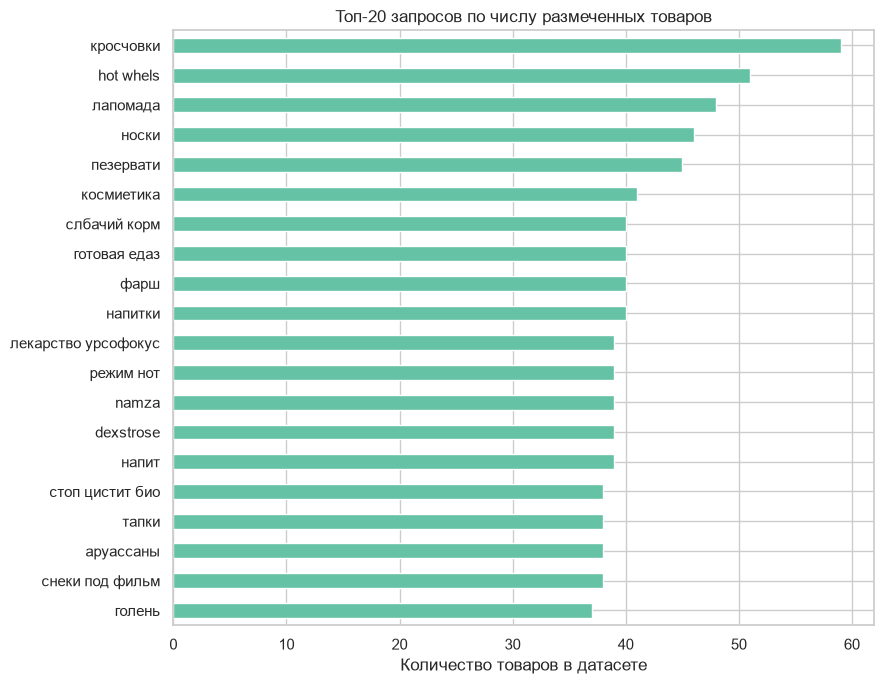

In [11]:
# Считаем, сколько товаров размечено для каждого запроса, берём топ-20 и сортируем для удобного графика.
top_queries = df["query"].value_counts().head(20).sort_values()

# Создаём область для графика размером 9 на 7 дюймов.
plt.figure(figsize=(9, 7))

# Строим горизонтальную диаграмму популярных запросов.
ax = top_queries.plot(kind="barh")

# Добавляем заголовок графика.
ax.set_title("Топ-20 запросов по числу размеченных товаров")

# Подписываем ось X.
ax.set_xlabel("Количество товаров в датасете")

# Убираем подпись оси Y, потому что сами запросы уже показаны как метки.
ax.set_ylabel("")

# Подгоняем отступы, чтобы длинные запросы не обрезались.
plt.tight_layout()

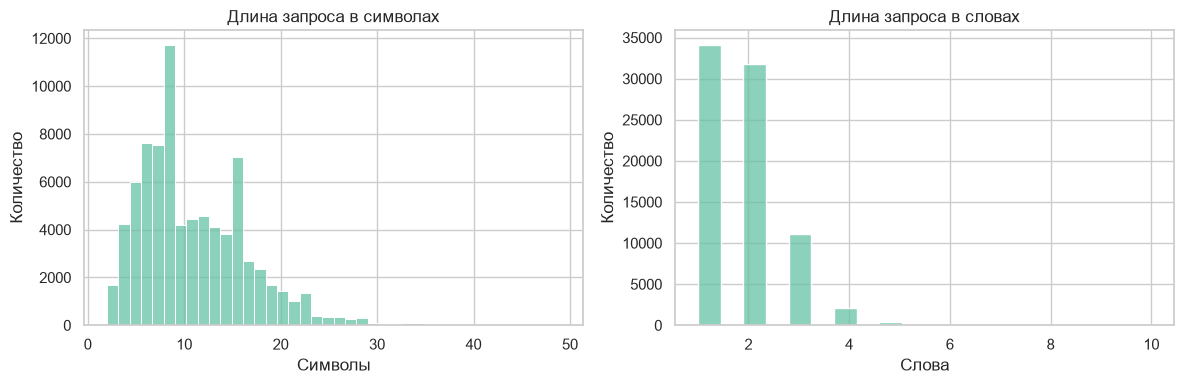

In [12]:
# Создаём фигуру с двумя графиками в одной строке.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Рисуем гистограмму длины запроса в символах.
sns.histplot(df["query_len"], bins=40, ax=axes[0])

# Добавляем заголовок первому графику.
axes[0].set_title("Длина запроса в символах")

# Подписываем ось X первого графика.
axes[0].set_xlabel("Символы")

# Подписываем ось Y первого графика.
axes[0].set_ylabel("Количество")

# Рисуем гистограмму длины запроса в словах.
sns.histplot(df["query_words"], bins=20, ax=axes[1])

# Добавляем заголовок второму графику.
axes[1].set_title("Длина запроса в словах")

# Подписываем ось X второго графика.
axes[1].set_xlabel("Слова")

# Подписываем ось Y второго графика.
axes[1].set_ylabel("Количество")

# Подгоняем отступы между двумя графиками.
plt.tight_layout()

In [13]:
# Выбираем примеры очень коротких запросов, которые часто бывают сокращениями, опечатками или неполным вводом.
short_queries = (
    # Фильтруем запросы длиной до 4 символов и оставляем только самые полезные колонки для просмотра.
    df.loc[df["query_len"] <= 4, ["query", "item_name", "final_answer", "category1_name"]]
    # Убираем полностью одинаковые строки, чтобы примеры не повторялись.
    .drop_duplicates()
    # Оставляем первые 30 строк для ручного просмотра.
    .head(30)
)

# Выводим таблицу коротких запросов.
short_queries

,query,item_name,final_answer,category1_name
18,туал,"бумага туалетная самокат 2 слоя, 8 рулонов",E,гигиена
43,шима,"пюре тёма, цыплёнок, с 6 месяцев, в железной банке, 90 г",I,детское питание
50,кокт,"молочный коктейль самокат, 2,5%, банан, с 12 месяцев, 205 г",E,детское питание
60,баэ,"мицеллярная вода aevit by librederm, basic care, 5 в 1, для всех типов кожи, 200 мл",I,уход
78,мист,"мастика с.пудовъ сахарная, жёлтая, 100 г",I,бакалея
82,rich,"маска riche laabs r-plex, с пептидами, для восстановления повреждённых волос, 250 мл",I,уход
99,pici,"игровой набор fisher-price, corgi tummy time, 3 в 1, 1 шт.",I,детские товары
123,h m,"женские брюки h&m, бежевые, s",E,одежда
127,таор,"творог самокат, 5%, из козьего молока, 100 г",E,молочная продукция
134,brit,"корм сухой для кошек brit brit premium sterilised, курица, 400 г",E,продукция для животных


### 2.4 Простейший текстовый признак: пересечение слов

Посчитаем, какая доля слов запроса встречается в названии товара. Это не модель, но хороший baseline-признак для задачи релевантности.

In [14]:
# Объявляем функцию, которая считает долю слов запроса, найденных в названии товара.
def word_overlap_share(query: str, item_name: str) -> float:
    # Приводим запрос к строке, нижнему регистру, разбиваем на слова и убираем повторы через set.
    query_words = set(str(query).lower().split())

    # Аналогично превращаем название товара в множество слов.
    item_words = set(str(item_name).lower().split())

    # Если в запросе нет слов, возвращаем np.nan, чтобы не делить на ноль.
    if not query_words:
        return np.nan

    # Считаем долю слов запроса, которые встретились среди слов названия товара.
    return len(query_words & item_words) / len(query_words)


# Добавляем в DataFrame новый признак с долей пересечения слов запроса и товара.
df["query_item_word_overlap"] = [
    # Для каждой пары query-item вызываем функцию word_overlap_share.
    word_overlap_share(query, item_name)
    # zip попарно проходит по колонкам query и item_name.
    for query, item_name in zip(df["query"], df["item_name"])
]

# Показываем первые 10 строк с новым признаком для быстрой проверки.
df[["query", "item_name", "final_answer", "query_item_word_overlap"]].head(10)

,query,item_name,final_answer,query_item_word_overlap
0,энергетик без сахара,"энергетик самокат, без сахара, с соком малины, 0,33 л",E,0.666667
1,салат из рубца,"салат кх волкова а. п. деревенский, 150 г",S,0.333333
2,барилла,"макароны barilla, пенне ригате, 450 г",E,0.000000
3,краска для волос орех,"спрей-уход для наращенных волос tashe 250 мл, 1 шт.",C,0.500000
4,творог мя,"творог козочка с облачка, 5%, мягкий, из козьего молока, кокосовые сливки, 100 г",E,0.500000
5,масло детское,"масло массажное заводъ братьевъ крестовниковыхъ | традиции качества, детство, 83 г",E,0.500000
6,холодец э,"патчи для глаз tony moly, 10 мл",I,0.000000
7,чипсы эсте,"чипсы lay’s stix, со вкусом кетчупа, 125 г",S,0.500000
8,следки мужские,"мужской свитшот adidas herren essentials 3-streifen sweatshirt, серый, 2xl",I,0.000000
9,котлеты охлажденное,"котлеты самокат, из индейки и цыплёнка-бройлера, с сыром чеддер, охлаждённые, 400 г",E,0.500000


In [15]:
# Считаем статистику признака word_overlap отдельно для каждой ESCI-метки.
overlap_summary = (
    # Группируем строки по метке релевантности.
    df.groupby("final_answer", dropna=False)["query_item_word_overlap"]
    # Для каждой группы считаем количество, среднее и медиану.
    .agg(["count", "mean", "median"])
    # Расставляем строки в порядке E, S, C, I.
    .reindex(label_order)
)

# Выводим итоговую таблицу статистик.
overlap_summary

,count,mean,median
final_answer,,,
E,36474,0.357419,0.333333
S,9307,0.334727,0.500000
C,4833,0.079140,0.000000
I,29160,0.036101,0.000000


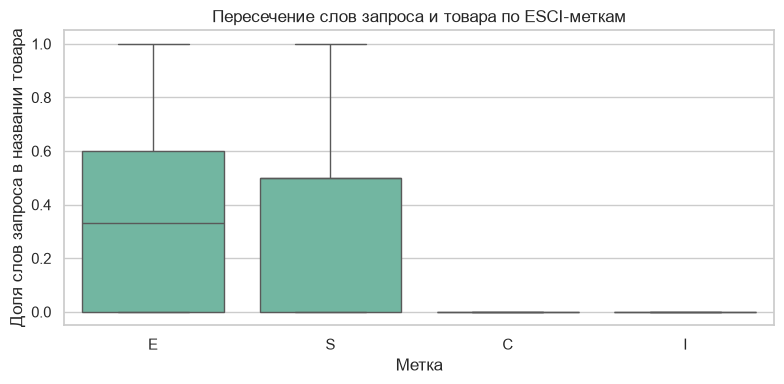

In [16]:
# Создаём область для графика размером 8 на 4 дюйма.
plt.figure(figsize=(8, 4))

# Строим boxplot, чтобы сравнить распределение word_overlap между ESCI-метками.
ax = sns.boxplot(
    # Указываем таблицу-источник.
    data=df,
    # По оси X идут ESCI-метки.
    x="final_answer",
    # По оси Y идёт доля слов запроса, найденных в названии товара.
    y="query_item_word_overlap",
    # Фиксируем порядок меток на оси X.
    order=label_order,
    # Скрываем выбросы, чтобы основной диапазон было легче читать.
    showfliers=False,
)

# Добавляем заголовок графика.
ax.set_title("Пересечение слов запроса и товара по ESCI-меткам")

# Подписываем ось X.
ax.set_xlabel("Метка")

# Подписываем ось Y.
ax.set_ylabel("Доля слов запроса в названии товара")

# Подгоняем отступы графика.
plt.tight_layout()

Идея, что просто по доле подстроки можно понять какой класс?

## 3. Граф заменителей из S-меток

Построим граф товаров, где узлы — товары, а рёбра — связь замены. Если для одного запроса есть точные товары `E` и заменители `S`, связываем `S`-товары с `E`-товарами. Если для запроса нет `E`, но есть несколько `S`, связываем `S`-товары между собой: они закрывают похожую потребность пользователя.

Вес ребра — количество уникальных запросов, которые поддерживают такую связь.

### 3.1 Создание графа

In [17]:
# defaultdict удобно использовать, когда нужно автоматически создавать пустую структуру для нового ребра.
from collections import defaultdict

# combinations помогает строить все пары товаров внутри группы S-товаров.
from itertools import combinations

# networkx нужен для построения и визуализации графов.
try:
    import networkx as nx
except ImportError as exc:
    raise ImportError("Установите networkx: выполните `%pip install networkx` в ячейке выше.") from exc


# Функция укорачивает длинные названия товаров для подписей на статичном графе.
def compact_label(text: str, max_len: int = 38) -> str:
    # Переводим значение в строку и обрезаем его только при превышении лимита.
    text = str(text)
    return text if len(text) <= max_len else text[: max_len - 1] + "…"


# Функция создаёт networkx-граф для Plotly или статичной визуализации.
def prepare_graph_view(
    edge_table_source,
    min_edge_weight,
    max_edges=None,
    category_filter=None,
    keep_all_components=False,
):
    # Начинаем с полной таблицы рёбер выбранного типа: S или C.
    selected_edges = edge_table_source.copy()

    # При заданной категории оставляем связи, где хотя бы один товар к ней относится.
    if category_filter is not None:
        selected_edges = selected_edges[
            selected_edges["item_a_category1"].eq(category_filter)
            | selected_edges["item_b_category1"].eq(category_filter)
        ]

    # Оставляем только связи, подтверждённые нужным числом запросов.
    selected_edges = selected_edges[
        selected_edges["weight"] >= min_edge_weight
    ]

    # Числовой лимит оставляет заданное число сильнейших рёбер; None сохраняет все рёбра.
    if max_edges is not None:
        selected_edges = selected_edges.head(max_edges)

    # Если порог слишком строгий, используем самые сильные рёбра без фильтра веса.
    if selected_edges.empty:
        selected_edges = edge_table_source.copy()
        if max_edges is not None:
            selected_edges = selected_edges.head(max_edges)

    # Создаём неориентированный граф из отобранных строк.
    graph = nx.Graph()
    for row in selected_edges.itertuples(index=False):
        # Добавляем оба товара вместе с полным и коротким названием и категорией.
        graph.add_node(
            row.item_a_id,
            name=row.item_a_name,
            label=compact_label(row.item_a_name),
            category=row.item_a_category1,
        )
        graph.add_node(
            row.item_b_id,
            name=row.item_b_name,
            label=compact_label(row.item_b_name),
            category=row.item_b_category1,
        )

        # Добавляем связь и сохраняем её вес, тип и примеры запросов.
        graph.add_edge(
            row.item_a_id,
            row.item_b_id,
            weight=row.weight,
            edge_type=row.edge_type,
            query_examples=row.query_examples,
        )

    # Пустой граф нельзя передать в connected_components.
    if graph.number_of_nodes() == 0:
        raise ValueError("После фильтрации не осталось товаров для графа.")

    # Для общего вида сохраняем все компоненты; для локального вида можно оставить крупнейшую.
    if keep_all_components:
        graph_view = graph.copy()
    else:
        largest_component = max(nx.connected_components(graph), key=len)
        graph_view = graph.subgraph(largest_component).copy()

    # Одни координаты используются обеими визуализациями, поэтому графики совпадают.
    positions = nx.spring_layout(graph_view, seed=42, k=0.9, weight="weight")
    return graph_view, positions


# Функция превращает подготовленный networkx-граф в интерактивную Plotly-фигуру.
def make_plotly_graph(
    graph,
    positions,
    strength_table,
    title,
    category_color_map=None,
):
    # Создаём пустую фигуру: рёбра добавятся раньше узлов и останутся на фоне.
    figure = go.Figure()

    # Вес связи кодируется толщиной и прозрачностью линии.
    edge_bands = [
        {"name": "Вес 1–2", "min": 1, "max": 2, "width": 0.8, "color": "rgba(100, 116, 139, 0.28)"},
        {"name": "Вес 3–4", "min": 3, "max": 4, "width": 1.4, "color": "rgba(71, 85, 105, 0.48)"},
        {"name": "Вес 5+", "min": 5, "max": float("inf"), "width": 2.2, "color": "rgba(30, 41, 59, 0.72)"},
    ]

    # Все рёбра одного диапазона объединяем в один быстрый Plotly trace.
    for band_index, band in enumerate(edge_bands):
        edge_x = []
        edge_y = []
        for source_id, target_id, edge_info in graph.edges(data=True):
            if not band["min"] <= edge_info["weight"] <= band["max"]:
                continue
            source_x, source_y = positions[source_id]
            target_x, target_y = positions[target_id]
            edge_x.extend([source_x, target_x, None])
            edge_y.extend([source_y, target_y, None])

        # Не добавляем пустой trace, если в диапазоне нет рёбер.
        if edge_x:
            figure.add_trace(
                go.Scatter(
                    x=edge_x,
                    y=edge_y,
                    mode="lines",
                    name=band["name"],
                    legendgroup="edge_weight",
                    legendgrouptitle_text="Вес связи" if band_index == 0 else None,
                    line={"width": band["width"], "color": band["color"]},
                    hoverinfo="skip",
                )
            )

    # Категория задаёт цвет узла и отдельный пункт легенды.
    category_palette = qualitative.Plotly + qualitative.Safe
    category_names = sorted(
        {node_info["category"] for _, node_info in graph.nodes(data=True)}
    )

    # Если готовая карта цветов не передана, строим её по категориям текущего графа.
    if category_color_map is None:
        category_color_map = {
            category_name: category_palette[index % len(category_palette)]
            for index, category_name in enumerate(category_names)
        }

    for category_index, category_name in enumerate(category_names):
        node_ids = [
            node_id
            for node_id, node_info in graph.nodes(data=True)
            if node_info["category"] == category_name
        ]
        hover_data = [
            [
                graph.nodes[node_id]["name"],
                category_name,
                graph.degree(node_id),
                int(strength_table.loc[node_id, "total_weight"]),
            ]
            for node_id in node_ids
        ]

        # Размер маркера зависит от числа соседей товара.
        marker_sizes = [7 + 2.2 * graph.degree(node_id) ** 0.5 for node_id in node_ids]
        figure.add_trace(
            go.Scatter(
                x=[positions[node_id][0] for node_id in node_ids],
                y=[positions[node_id][1] for node_id in node_ids],
                mode="markers",
                name=category_name,
                legendgroup="categories",
                legendgrouptitle_text="Категория" if category_index == 0 else None,
                customdata=hover_data,
                hovertemplate=(
                    "<b>%{customdata[0]}</b><br>"
                    "Категория: %{customdata[1]}<br>"
                    "Число соседей: %{customdata[2]}<br>"
                    "Суммарный вес: %{customdata[3]}"
                    "<extra></extra>"
                ),
                marker={
                    "size": marker_sizes,
                    "color": category_color_map[category_name],
                    "opacity": 0.9,
                    "line": {"width": 0.7, "color": "white"},
                },
            )
        )

    # Настраиваем область графа, легенду и интерактивное перемещение.
    figure.update_layout(
        title=title,
        template="plotly_white",
        height=820,
        hovermode="closest",
        dragmode="pan",
        margin={"l": 20, "r": 20, "t": 70, "b": 20},
        legend={"x": 1.01, "y": 1, "xanchor": "left", "yanchor": "top"},
    )
    figure.update_xaxes(visible=False, showgrid=False, zeroline=False)
    figure.update_yaxes(
        visible=False, showgrid=False, zeroline=False, scaleanchor="x", scaleratio=1
    )
    return figure

In [18]:
# Сохраняем короткий справочник по товарам: по item_id можно быстро получить название и категорию.
item_lookup = (
    # Берём только нужные колонки для описания узлов графа.
    df[["item_id", "item_name", "category1_name", "category2_name"]]
    # Убираем дубли item_id, чтобы один товар был представлен одной строкой.
    .drop_duplicates("item_id")
    # Делаем item_id индексом, чтобы потом обращаться к товару по идентификатору.
    .set_index("item_id")
    # Превращаем таблицу в словарь вида item_id -> {item_name, category1_name, category2_name}.
    .to_dict("index")
)

# В edge_data будем копить связи между товарами и запросы, которые подтверждают каждую связь.
edge_data = defaultdict(lambda: {"queries": set(), "edge_types": set()})

# Для графа заменителей нужны только точные товары E и заменители S.
es_df = df[df["final_answer"].isin(["E", "S"])].copy()

# Группируем данные по поисковому запросу: смысл замены определяется внутри одного пользовательского запроса.
for query, query_part in es_df.groupby("query"):
    # Находим все уникальные товары с меткой E для текущего запроса.
    exact_items = query_part.loc[query_part["final_answer"].eq("E"), "item_id"].drop_duplicates().tolist()

    # Находим все уникальные товары с меткой S для текущего запроса.
    substitute_items = query_part.loc[query_part["final_answer"].eq("S"), "item_id"].drop_duplicates().tolist()

    # Если заменителей нет, из этого запроса нельзя построить S-связь.
    if not substitute_items:
        continue

    # Если есть точные товары, считаем каждый S-товар заменой для каждого E-товара.
    if exact_items:
        # Перебираем товары-заменители.
        for substitute_id in substitute_items:
            # Перебираем точные товары для этого же запроса.
            for exact_id in exact_items:
                # Не строим петлю, если вдруг один и тот же товар получил разные метки.
                if substitute_id == exact_id:
                    continue

                # Сортируем пару item_id, потому что граф неориентированный: A-B и B-A — одно ребро.
                edge_key = tuple(sorted((substitute_id, exact_id)))

                # Добавляем запрос, который подтверждает эту связь.
                edge_data[edge_key]["queries"].add(str(query))

                # Запоминаем тип связи: заменитель связан с точным товаром.
                edge_data[edge_key]["edge_types"].add("S-E")

    # Если E-товаров нет, но S-товаров несколько, связываем S-товары между собой.
    elif len(substitute_items) > 1:
        # combinations строит все пары S-товаров для текущего запроса.
        for item_a_id, item_b_id in combinations(substitute_items, 2):
            # Сортируем пару item_id для неориентированного графа.
            edge_key = tuple(sorted((item_a_id, item_b_id)))

            # Добавляем запрос, который связывает эту пару заменителей.
            edge_data[edge_key]["queries"].add(str(query))

            # Запоминаем тип связи: два S-товара для одной потребности.
            edge_data[edge_key]["edge_types"].add("S-S")

# Проверяем, сколько связей удалось построить.
print(f"Построено рёбер: {len(edge_data):,}".replace(",", " "))

Построено рёбер: 42 183


In [19]:
# Превращаем словарь рёбер в обычную таблицу, чтобы её можно было сортировать и анализировать.
edge_rows = []

# Проходим по всем найденным связям между парами товаров.
for (item_a_id, item_b_id), edge_info in edge_data.items():
    # Достаём описание первого товара из справочника item_lookup.
    item_a = item_lookup[item_a_id]

    # Достаём описание второго товара из справочника item_lookup.
    item_b = item_lookup[item_b_id]

    # Сортируем несколько примеров запросов, чтобы вывод был стабильным.
    query_examples = sorted(edge_info["queries"])

    # Добавляем одну строку таблицы для текущего ребра.
    edge_rows.append(
        {
            # Идентификатор первого товара.
            "item_a_id": item_a_id,
            # Название первого товара.
            "item_a_name": item_a["item_name"],
            # Категория первого товара верхнего уровня.
            "item_a_category1": item_a["category1_name"],
            # Идентификатор второго товара.
            "item_b_id": item_b_id,
            # Название второго товара.
            "item_b_name": item_b["item_name"],
            # Категория второго товара верхнего уровня.
            "item_b_category1": item_b["category1_name"],
            # Вес ребра: сколько разных запросов поддерживают эту связь.
            "weight": len(edge_info["queries"]),
            # Типы связи, которые встретились для этой пары: S-E, S-S или оба варианта.
            "edge_type": "/".join(sorted(edge_info["edge_types"])),
            # Несколько примеров запросов, по которым возникла связь.
            "query_examples": ", ".join(query_examples[:5]),
        }
    )

# Создаём DataFrame из списка рёбер и сортируем самые сильные связи наверх.
edge_table = (
    pd.DataFrame(edge_rows)
    .sort_values(["weight", "item_a_name", "item_b_name"], ascending=[False, True, True])
    .reset_index(drop=True)
)

# Показываем 15 самых сильных связей заменителей.
edge_table.head(15)

,item_a_id,item_a_name,item_a_category1,item_b_id,item_b_name,item_b_category1,weight,edge_type,query_examples
0,94e144acc19a5ec3d8e527f533e8268a,"ржано-пшеничный хлеб черёмушки, столичный, половинка, нарезка, 330 г",хлеб и хлебобулочные изделия,d43f5d9febdc5798a899adecdca0073e,"ржано-пшеничный хлеб коломенский, ржаной край, заварной, в нарезке, 300 г",хлеб и хлебобулочные изделия,19,S-S,"горячее хлеб, маисовый хлеб, ржаной аш, родные просторы хлеб, хлеб живая"
1,4b5aeeb49fc0a4f6e0303a3b8302f5c3,"ржано-пшеничный хлеб коломенский, дарницкий, нарезка, 350 г",хлеб и хлебобулочные изделия,d43f5d9febdc5798a899adecdca0073e,"ржано-пшеничный хлеб коломенский, ржаной край, заварной, в нарезке, 300 г",хлеб и хлебобулочные изделия,17,S-S,"горячее хлеб, маисовый хлеб, ржаной аш, родные просторы хлеб, хлеб живая"
2,4b5aeeb49fc0a4f6e0303a3b8302f5c3,"ржано-пшеничный хлеб коломенский, дарницкий, нарезка, 350 г",хлеб и хлебобулочные изделия,94e144acc19a5ec3d8e527f533e8268a,"ржано-пшеничный хлеб черёмушки, столичный, половинка, нарезка, 330 г",хлеб и хлебобулочные изделия,17,S-S,"горячее хлеб, маисовый хлеб, ржаной аш, родные просторы хлеб, хлеб живая"
3,72ff94d53745a6531f85a3648afaf050,"ржано-пшеничный хлеб черёмушки, зерновик, мультизлаковый, нарезка, 460 г",хлеб и хлебобулочные изделия,d43f5d9febdc5798a899adecdca0073e,"ржано-пшеничный хлеб коломенский, ржаной край, заварной, в нарезке, 300 г",хлеб и хлебобулочные изделия,17,S-E/S-S,"горячее хлеб, маисовый хлеб, мульти зерновой хлеб, ржаной аш, хлеб живая"
4,72ff94d53745a6531f85a3648afaf050,"ржано-пшеничный хлеб черёмушки, зерновик, мультизлаковый, нарезка, 460 г",хлеб и хлебобулочные изделия,94e144acc19a5ec3d8e527f533e8268a,"ржано-пшеничный хлеб черёмушки, столичный, половинка, нарезка, 330 г",хлеб и хлебобулочные изделия,17,S-E/S-S,"горячее хлеб, маисовый хлеб, мульти зерновой хлеб, ржаной аш, хлеб живая"
5,4b5aeeb49fc0a4f6e0303a3b8302f5c3,"ржано-пшеничный хлеб коломенский, дарницкий, нарезка, 350 г",хлеб и хлебобулочные изделия,72ff94d53745a6531f85a3648afaf050,"ржано-пшеничный хлеб черёмушки, зерновик, мультизлаковый, нарезка, 460 г",хлеб и хлебобулочные изделия,15,S-E/S-S,"горячее хлеб, маисовый хлеб, мульти зерновой хлеб, ржаной аш, хлеб живая"
6,4b5aeeb49fc0a4f6e0303a3b8302f5c3,"ржано-пшеничный хлеб коломенский, дарницкий, нарезка, 350 г",хлеб и хлебобулочные изделия,997663caf7d285fdde495e13d5b23eda,"хлеб самокат тартин, пшенично-ржаной, половинка, нарезка, 300 г",хлеб и хлебобулочные изделия,15,S-S,"горячее хлеб, маисовый хлеб, родные просторы хлеб, хлеб живая, хлеб легкое"
7,3683d35d5152818437b5fd843c41bcee,"ржано-пшеничный хлеб черёмушки, бородинский, половинка, нарезка, 390 г",хлеб и хлебобулочные изделия,d43f5d9febdc5798a899adecdca0073e,"ржано-пшеничный хлеб коломенский, ржаной край, заварной, в нарезке, 300 г",хлеб и хлебобулочные изделия,15,S-S,"горячее хлеб, маисовый хлеб, ржаной аш, родные просторы хлеб, хлеб живая"
8,3683d35d5152818437b5fd843c41bcee,"ржано-пшеничный хлеб черёмушки, бородинский, половинка, нарезка, 390 г",хлеб и хлебобулочные изделия,94e144acc19a5ec3d8e527f533e8268a,"ржано-пшеничный хлеб черёмушки, столичный, половинка, нарезка, 330 г",хлеб и хлебобулочные изделия,15,S-S,"горячее хлеб, маисовый хлеб, ржаной аш, родные просторы хлеб, хлеб живая"
9,72ff94d53745a6531f85a3648afaf050,"ржано-пшеничный хлеб черёмушки, зерновик, мультизлаковый, нарезка, 460 г",хлеб и хлебобулочные изделия,9323f92430db0096beecb29920270b4e,"ржано-пшеничный хлеб даниловский, бездрожжевой, 350 г",хлеб и хлебобулочные изделия,15,S-E/S-S,"горячее хлеб, маисовый хлеб, мульти зерновой хлеб, ржаной аш, хлеб живая"


In [20]:
# Считаем, какие товары чаще всего оказываются в сильных связях замены.
node_strength = (
    # melt превращает две колонки item_a_id/item_b_id в одну колонку item_id.
    edge_table.melt(
        # Вес ребра сохраняем как значение, которое потом будем суммировать.
        id_vars=["weight"],
        # Эти две колонки содержат товары на разных концах ребра.
        value_vars=["item_a_id", "item_b_id"],
        # Название новой колонки с item_id.
        value_name="item_id",
    )
    # Группируем по товару.
    .groupby("item_id")
    # total_weight — суммарная сила связей, edge_count — число соседей/рёбер.
    .agg(total_weight=("weight", "sum"), edge_count=("weight", "size"))
    # Сначала показываем товары с максимальной суммарной силой связей.
    .sort_values(["total_weight", "edge_count"], ascending=False)
)

# Добавляем человекочитаемое название товара.
node_strength["item_name"] = node_strength.index.map(lambda item_id: item_lookup[item_id]["item_name"])

# Добавляем категорию верхнего уровня.
node_strength["category1_name"] = node_strength.index.map(lambda item_id: item_lookup[item_id]["category1_name"])

# Показываем самые центральные товары в графе заменителей.
node_strength.head(20)

,total_weight,edge_count,item_name,category1_name
item_id,,,,
997663caf7d285fdde495e13d5b23eda,226,46,"хлеб самокат тартин, пшенично-ржаной, половинка, нарезка, 300 г",хлеб и хлебобулочные изделия
94e144acc19a5ec3d8e527f533e8268a,222,27,"ржано-пшеничный хлеб черёмушки, столичный, половинка, нарезка, 330 г",хлеб и хлебобулочные изделия
d43f5d9febdc5798a899adecdca0073e,221,27,"ржано-пшеничный хлеб коломенский, ржаной край, заварной, в нарезке, 300 г",хлеб и хлебобулочные изделия
4b5aeeb49fc0a4f6e0303a3b8302f5c3,215,28,"ржано-пшеничный хлеб коломенский, дарницкий, нарезка, 350 г",хлеб и хлебобулочные изделия
72ff94d53745a6531f85a3648afaf050,204,28,"ржано-пшеничный хлеб черёмушки, зерновик, мультизлаковый, нарезка, 460 г",хлеб и хлебобулочные изделия
3683d35d5152818437b5fd843c41bcee,189,27,"ржано-пшеничный хлеб черёмушки, бородинский, половинка, нарезка, 390 г",хлеб и хлебобулочные изделия
9323f92430db0096beecb29920270b4e,181,31,"ржано-пшеничный хлеб даниловский, бездрожжевой, 350 г",хлеб и хлебобулочные изделия
6f9a93cd91569d45f48cc8523e09aba8,181,26,хлеб ржано-пшеничный самокат деревенский 300 г,хлеб и хлебобулочные изделия
1139984bcc69e84e2cd99ba5028a5e54,180,32,"хлеб хлебный дом, геркулес, с отрубями, нарезка, 250 г",хлеб и хлебобулочные изделия


### 3.2 Визуализируем весь граф заменителей

Создаём общий `G_plot` со всеми связными компонентами и одну раскладку `pos`. В интерактивной Plotly-версии можно приближать отдельные группы, перемещаться по графу и смотреть информацию о товарах при наведении.


In [21]:
# Если Plotly или nbformat не установлены, выполните в отдельной ячейке: %pip install plotly "nbformat>=4.2.0"
import plotly.graph_objects as go
from plotly.colors import qualitative

# None оставляет все категории; при необходимости сюда можно записать название категории.
CATEGORY_FILTER = None

# Показываем связи, подтверждённые минимум двумя запросами.
MIN_EDGE_WEIGHT = 2

# None отключает ограничение: в интерактивный граф попадут все подходящие рёбра.
MAX_EDGES = None

# Создаём полный граф и сохраняем все его связные компоненты.
G_plot, pos = prepare_graph_view(
    edge_table,
    min_edge_weight=MIN_EDGE_WEIGHT,
    max_edges=MAX_EDGES,
    category_filter=CATEGORY_FILTER,
    keep_all_components=True,
)

# Строим интерактивную фигуру из реально существующих G_plot и pos.
fig = make_plotly_graph(
    G_plot,
    pos,
    node_strength,
    title=(
        f"Весь интерактивный граф заменителей: {G_plot.number_of_nodes()} товаров, "
        f"{G_plot.number_of_edges()} связей, вес ребра >= {MIN_EDGE_WEIGHT}"
    ),
)

# Показываем Plotly-фигуру прямо в VS Code/Jupyter.
fig.show(config={"scrollZoom": True, "displaylogo": False, "responsive": True})


### 3.3 Три крупнейшие связные компоненты

Разделим общий граф на связные компоненты, отсортируем их по числу товаров и отдельно покажем топ-1, топ-2 и топ-3. Для каждой компоненты строится собственная интерактивная Plotly-визуализация.


In [29]:
# connected_components возвращает множество item_id для каждой отдельной компоненты графа.
all_components = list(nx.connected_components(G_plot))

# Сортируем компоненты по числу товаров от самой большой к самой маленькой.
components_by_size = sorted(all_components, key=len, reverse=True)

# Оставляем первые три компоненты: топ-1, топ-2 и топ-3 по количеству товаров.
top_components = components_by_size[:3]

# Собираем все категории общего графа, чтобы их цвета совпадали на трёх визуализациях.
all_category_names = sorted(
    {node_info["category"] for _, node_info in G_plot.nodes(data=True)}
)

# Объединяем две качественные палитры Plotly для достаточного количества категорий.
category_palette = qualitative.Plotly + qualitative.Safe

# Сопоставляем каждой категории постоянный цвет.
category_color_map = {
    category_name: category_palette[index % len(category_palette)]
    for index, category_name in enumerate(all_category_names)
}

# Сюда сохраним три networkx-графа и три Plotly-фигуры для дальнейшей работы.
top_component_graphs = []
top_component_figures = []

# По очереди строим отдельный интерактивный граф для каждой компоненты.
for component_rank, component_nodes in enumerate(top_components, start=1):
    # Создаём независимую копию подграфа, содержащую только узлы текущей компоненты.
    component_graph = G_plot.subgraph(component_nodes).copy()

    # Заново рассчитываем координаты, чтобы компонента занимала всю область своего графика.
    component_pos = nx.spring_layout(
        component_graph,
        seed=42,
        k=0.9,
        weight="weight",
    )

    # Формируем заголовок с местом компоненты и её фактическими размерами.
    component_title = (
        f"Топ-{component_rank} связная компонента: "
        f"{component_graph.number_of_nodes()} товаров, "
        f"{component_graph.number_of_edges()} связей"
    )

    # Превращаем networkx-подграф в интерактивную Plotly-фигуру.
    component_figure = make_plotly_graph(
        component_graph,
        component_pos,
        node_strength,
        title=component_title,
        category_color_map=category_color_map,
    )

    # Сохраняем объекты, чтобы к ним можно было обратиться в следующих ячейках.
    top_component_graphs.append(component_graph)
    top_component_figures.append(component_figure)

    # Показываем текущую компоненту прямо в VS Code/Jupyter.
    component_figure.show(
        config={"scrollZoom": True, "displaylogo": False, "responsive": True}
    )


## 4. Граф сопутствующих товаров из C-меток

Построим второй граф по той же схеме, но для метки `C` (`Complement`). Узлы — товары, а ребро `C–E` связывает сопутствующий товар с точным результатом того же запроса. Если точного товара `E` нет, несколько `C`-товаров связываются как совместно встретившиеся вокруг одной потребности (`C–C`).

Вес ребра — количество уникальных запросов, которые подтверждают такую связь.

In [23]:
# Создаём справочник товаров для C-графа: item_id -> название и категория.
c_item_lookup = (
    df[["item_id", "item_name", "category1_name"]]
    .drop_duplicates("item_id")
    .set_index("item_id")
    .to_dict("index")
)

# Для каждой пары храним уникальные запросы и типы C-связи.
c_edge_data = defaultdict(lambda: {"queries": set(), "edge_types": set()})

# Для построения C-графа нужны только точные E и сопутствующие C результаты.
ec_df = df[df["final_answer"].isin(["E", "C"])].copy()

# Рассматриваем товары отдельно внутри каждого пользовательского запроса.
for query, query_part in ec_df.groupby("query"):
    # Находим уникальные точные товары E текущего запроса.
    exact_items = (
        query_part.loc[query_part["final_answer"].eq("E"), "item_id"]
        .drop_duplicates()
        .tolist()
    )

    # Находим уникальные сопутствующие товары C текущего запроса.
    complement_items = (
        query_part.loc[query_part["final_answer"].eq("C"), "item_id"]
        .drop_duplicates()
        .tolist()
    )

    # Если C-товаров нет, этот запрос не создаёт связи в C-графе.
    if not complement_items:
        continue

    # При наличии точных результатов соединяем каждый C-товар с каждым E-товаром.
    if exact_items:
        for complement_id in complement_items:
            for exact_id in exact_items:
                # Не создаём петлю, если один item_id неожиданно получил обе метки.
                if complement_id == exact_id:
                    continue

                # Сортируем пару, потому что граф неориентированный.
                edge_key = tuple(sorted((complement_id, exact_id)))

                # Запоминаем запрос и тип связи C–E.
                c_edge_data[edge_key]["queries"].add(str(query))
                c_edge_data[edge_key]["edge_types"].add("C-E")

    # Без E связываем между собой несколько C-товаров одного запроса.
    elif len(complement_items) > 1:
        for item_a_id, item_b_id in combinations(complement_items, 2):
            # Сортируем пару для единого ключа неориентированного ребра.
            edge_key = tuple(sorted((item_a_id, item_b_id)))

            # Запоминаем запрос и тип совместной C–C связи.
            c_edge_data[edge_key]["queries"].add(str(query))
            c_edge_data[edge_key]["edge_types"].add("C-C")

# Превращаем словарь C-рёбер в удобную таблицу.
c_edge_rows = []

# Добавляем в каждую строку названия товаров, категории, вес и примеры запросов.
for (item_a_id, item_b_id), edge_info in c_edge_data.items():
    item_a = c_item_lookup[item_a_id]
    item_b = c_item_lookup[item_b_id]
    query_examples = sorted(edge_info["queries"])

    c_edge_rows.append(
        {
            "item_a_id": item_a_id,
            "item_a_name": item_a["item_name"],
            "item_a_category1": item_a["category1_name"],
            "item_b_id": item_b_id,
            "item_b_name": item_b["item_name"],
            "item_b_category1": item_b["category1_name"],
            "weight": len(edge_info["queries"]),
            "edge_type": "/".join(sorted(edge_info["edge_types"])),
            "query_examples": ", ".join(query_examples[:5]),
        }
    )

# Сортируем C-связи: самые часто подтверждённые пары окажутся наверху.
c_edge_table = (
    pd.DataFrame(c_edge_rows)
    .sort_values(["weight", "item_a_name", "item_b_name"], ascending=[False, True, True], kind="stable")
    .reset_index(drop=True)
)

# Показываем самые сильные связи сопутствующих товаров.
print(f"Построено C-рёбер: {len(c_edge_table):,}".replace(",", " "))
c_edge_table.head(15)

Построено C-рёбер: 18 550


,item_a_id,item_a_name,item_a_category1,item_b_id,item_b_name,item_b_category1,weight,edge_type,query_examples
0,2cffa36529d5a22d178eea5029012167,"соус astoria, для шаурмы, чесночный, 200 г",бакалея,5f732b385d291520b500a78c105b37d2,"шаурма гриль вэй, со свининой, на углях, 180 г",кулинария,8,C-E,"для шаурм, шавермащ, шавермма, шакрмп, шаурма"
1,2cffa36529d5a22d178eea5029012167,"соус astoria, для шаурмы, чесночный, 200 г",бакалея,9cf6bee42a2b5bfaebaac29fd29cb10a,"шаурма шоколадница, в пите, 230 г",кулинария,8,C-E,"для шаурм, шавермащ, шавермма, шакрмп, шаурма"
2,3967640fc2e49ad3ad9d7458a8f9be8f,"филе грудки цыплят-бройлеров петелинка, по-мексикански, в соусе чураско, охлаждённое, 450 г",птица,e205b2c7cf8c383cbc27faaaa5092298,"приправа maggi, для нежного филе куриной грудки, по-итальянски, 30,6 г",бакалея,7,C-E,"грудка, грудка мясо, куриная грудка, куриное филе, филе грудки бройлера"
3,bc9bf0a4b31f39866845687ab11f4f33,"филе грудки цыплёнка-бройлера петелинка, кубики, охлаждённое, 550 г",птица,e205b2c7cf8c383cbc27faaaa5092298,"приправа maggi, для нежного филе куриной грудки, по-итальянски, 30,6 г",бакалея,7,C-E,"грудка, грудка мясо, куриная грудка, куриное филе, филе грудки бройлера"
4,032f07102f717e9b37483013274e72cc,"шаурма самокат, с курицей и аджикой, 170 г",кулинария,2cffa36529d5a22d178eea5029012167,"соус astoria, для шаурмы, чесночный, 200 г",бакалея,7,C-E,"для шаурм, шавермащ, шавермма, шакрмп, шаурма го"
5,2948c44c69fb24f65fd29bd5176edd35,"белый картофель, мытый, в сетке, 1 кг",свежие овощи,c13b7e6e2d1ec060918a7ec1a22c5497,"куриная котлета creative kitchen, с картофельным пюре, 260 г",кулинария,6,C-E,"кар, карт, карто, картофель, картошка"
6,2948c44c69fb24f65fd29bd5176edd35,"белый картофель, мытый, в сетке, 1 кг",свежие овощи,8d68283dab23251ff773aa2580fd2d01,"рыбные котлеты creative kitchen, из минтая, с картофельным пюре, 230 г",кулинария,6,C-E,"кар, карт, карто, картофель, картошка"
7,c13b7e6e2d1ec060918a7ec1a22c5497,"куриная котлета creative kitchen, с картофельным пюре, 260 г",кулинария,c60a648385eaa2eaefbe4c6757c4b0f1,"картофель, египет, новый урожай, 2 кг",свежие овощи,6,C-E,"кар, карт, карто, картофель, картошка"
8,8d68283dab23251ff773aa2580fd2d01,"рыбные котлеты creative kitchen, из минтая, с картофельным пюре, 230 г",кулинария,c60a648385eaa2eaefbe4c6757c4b0f1,"картофель, египет, новый урожай, 2 кг",свежие овощи,6,C-E,"кар, карт, карто, картофель, картошка"
9,dfe2557bcacb5d993658cdc2af039e2d,"сгущённое молоко алексеевское, 8,5%, с сахаром, цельное, дойпак, 650 г",консервированные продукты,ef18e926116b62f95754ed8b71a55e9f,"сырок творожный самокат в молочном шоколаде, со сгущённым варёным молоком, 5%, 40 г",молочная продукция,6,C-E,"сгущ, сгуще, сгущен, сгущенк, сгущенка"


In [24]:
# Считаем силу каждого товара в полном C-графе.
c_node_strength = (
    c_edge_table.melt(
        id_vars=["weight"],
        value_vars=["item_a_id", "item_b_id"],
        value_name="item_id",
    )
    .groupby("item_id")
    .agg(total_weight=("weight", "sum"), edge_count=("weight", "size"))
    .sort_values(["total_weight", "edge_count"], ascending=False)
)

# Добавляем названия и категории для интерпретации центральных товаров.
c_node_strength["item_name"] = c_node_strength.index.map(
    lambda item_id: c_item_lookup[item_id]["item_name"]
)
c_node_strength["category1_name"] = c_node_strength.index.map(
    lambda item_id: c_item_lookup[item_id]["category1_name"]
)

# Показываем товары с максимальной суммарной силой C-связей.
c_node_strength.head(20)

,total_weight,edge_count,item_name,category1_name
item_id,,,,
2bf2290d1e4e2d3804f541f439ad5007,82,40,"хот-дог фабрика домодедово, с сосиской и жареным луком, 150 г",кулинария
011ff49c5596eaf244b3e378125b236c,69,49,"филе цыплёнка-бройлера троекурово, малое, охлаждённое, 450 г",птица
e205b2c7cf8c383cbc27faaaa5092298,68,40,"приправа maggi, для нежного филе куриной грудки, по-итальянски, 30,6 г",бакалея
2b854903cdb9274ca68be46c91c4517c,67,50,"филе цыплёнка-бройлера троекурово, охлаждённое, 900 г",птица
cedc9d7e18cebf1f2b54dd055a2257b4,65,55,"пельмени сибирская коллекция, сочные, с фаршем на молоке, 700 г",замороженные продукты
2948c44c69fb24f65fd29bd5176edd35,65,36,"белый картофель, мытый, в сетке, 1 кг",свежие овощи
c60a648385eaa2eaefbe4c6757c4b0f1,64,35,"картофель, египет, новый урожай, 2 кг",свежие овощи
c13b7e6e2d1ec060918a7ec1a22c5497,62,37,"куриная котлета creative kitchen, с картофельным пюре, 260 г",кулинария
973c74a6009779db75a14ebff29bd3b2,57,37,"хрустящие куриные крылышки горячая штучка, острые к пиву, заморозка, 300 г",замороженные продукты


### 4.1 Весь интерактивный граф C-связей

Создаём общий `G_c_plot` со всеми связными компонентами. В интерактивной Plotly-версии можно приближать отдельные группы, перемещаться по графу и смотреть информацию о товарах при наведении.


In [25]:
# Повторный импорт делает C-раздел независимым от выполнения Plotly-ячейки S-графа.
import plotly.graph_objects as go
from plotly.colors import qualitative

# None оставляет все категории; при необходимости сюда можно записать название категории.
C_CATEGORY_FILTER = None

# Для C-графа оставляем связи, подтверждённые минимум двумя запросами.
C_MIN_EDGE_WEIGHT = 2

# None отключает ограничение: в общий C-граф попадут все подходящие рёбра.
C_MAX_EDGES = None

# Создаём полный C-граф и сохраняем все его связные компоненты.
G_c_plot, c_pos = prepare_graph_view(
    c_edge_table,
    min_edge_weight=C_MIN_EDGE_WEIGHT,
    max_edges=C_MAX_EDGES,
    category_filter=C_CATEGORY_FILTER,
    keep_all_components=True,
)

# Собираем все категории C-графа для единой карты цветов общего вида и топ-компонент.
c_all_category_names = sorted(
    {node_info["category"] for _, node_info in G_c_plot.nodes(data=True)}
)

# Объединяем две качественные палитры Plotly для достаточного количества категорий.
c_category_palette = qualitative.Plotly + qualitative.Safe

# Сопоставляем каждой категории C-графа постоянный цвет.
c_category_color_map = {
    category_name: c_category_palette[index % len(c_category_palette)]
    for index, category_name in enumerate(c_all_category_names)
}

# Строим интерактивную фигуру всего C-графа.
c_fig = make_plotly_graph(
    G_c_plot,
    c_pos,
    c_node_strength,
    title=(
        f"Весь интерактивный C-граф: {G_c_plot.number_of_nodes()} товаров, "
        f"{G_c_plot.number_of_edges()} связей, вес ребра >= {C_MIN_EDGE_WEIGHT}"
    ),
    category_color_map=c_category_color_map,
)

# Показываем Plotly-фигуру прямо в VS Code/Jupyter.
c_fig.show(config={"scrollZoom": True, "displaylogo": False, "responsive": True})


### 4.2 Три крупнейшие связные компоненты C-графа

Разделим общий C-граф на связные компоненты, отсортируем их по числу товаров и отдельно покажем топ-1, топ-2 и топ-3. Для каждой компоненты строится собственная интерактивная Plotly-визуализация.


In [26]:
# connected_components возвращает множество item_id для каждой отдельной C-компоненты.
c_all_components = list(nx.connected_components(G_c_plot))

# Сортируем C-компоненты по числу товаров от самой большой к самой маленькой.
c_components_by_size = sorted(c_all_components, key=len, reverse=True)

# Оставляем первые три C-компоненты: топ-1, топ-2 и топ-3 по количеству товаров.
c_top_components = c_components_by_size[:3]

# Сюда сохраним три networkx-графа и три Plotly-фигуры для дальнейшей работы.
c_top_component_graphs = []
c_top_component_figures = []

# По очереди строим отдельный интерактивный граф для каждой C-компоненты.
for component_rank, component_nodes in enumerate(c_top_components, start=1):
    # Создаём независимую копию подграфа с товарами текущей C-компоненты.
    component_graph = G_c_plot.subgraph(component_nodes).copy()

    # Заново рассчитываем координаты, чтобы компонента занимала всю область своего графика.
    component_pos = nx.spring_layout(
        component_graph,
        seed=42,
        k=0.9,
        weight="weight",
    )

    # Формируем заголовок с местом C-компоненты и её фактическими размерами.
    component_title = (
        f"Топ-{component_rank} связная C-компонента: "
        f"{component_graph.number_of_nodes()} товаров, "
        f"{component_graph.number_of_edges()} связей"
    )

    # Превращаем networkx-подграф в интерактивную Plotly-фигуру.
    component_figure = make_plotly_graph(
        component_graph,
        component_pos,
        c_node_strength,
        title=component_title,
        category_color_map=c_category_color_map,
    )

    # Сохраняем объекты, чтобы к ним можно было обратиться в следующих ячейках.
    c_top_component_graphs.append(component_graph)
    c_top_component_figures.append(component_figure)

    # Показываем текущую C-компоненту прямо в VS Code/Jupyter.
    component_figure.show(
        config={"scrollZoom": True, "displaylogo": False, "responsive": True}
    )
